# Facial Heatmap Time Series Appear to be Constrained in a Highly Specific Way

> Analysis of time series embeddings 

In [ ]:
#| default_exp tfreq

In [ ]:
#| hide

import plotly.io as pio

In [ ]:
#| hide
pio.renderers.default = "png"

In [ ]:
#| hide
#| eval: false

from fhemb.config.settings import FEATURE
from fhemb.config.log_config import setup_logging

DEBUG:fhemb.config.settings:Loading environment from /Users/radned/.config/fhemb/.env.paths
DEBUG:fhemb.config.settings:Loading environment from /Users/radned/.config/fhemb/.env.db


In [ ]:
#| hide
#| eval: false

from fhemb.piece import Piece
from fhemb.utils.factories import wfactory, pca_factory

DEBUG:fhemb.config.settings:Loading environment from /Users/radned/.config/fhemb/.env.paths
DEBUG:fhemb.config.settings:Loading environment from /Users/radned/.config/fhemb/.env.db
DEBUG:fhemb.config.settings:Running locally


In [ ]:
#| hide
#| eval: false

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#| hide
#| eval: false

import logging


In [ ]:
#| hide 
#| eval: false

setup_logging()
logger = logging.getLogger('tfreq')

## Piece instances to analyze

In [ ]:
#| eval: false

dg0 = Piece(title='Don Giovanni', time_interval=(14200,16200), subjs=[(60,70)])

 [DEBUG] mixins.wrapper: wrapper of process_subjects called with subjs=[(60, 70)], args=() and kwargs={'title': 'Don Giovanni', 'time_interval': (14200, 16200)}
 [DEBUG] mixins.wrapper: Calling: get_piece_attribute_values with title=Don Giovanni and atributes=['number_of_subjects']
 [DEBUG] mixins.wrapper: to get subjects_int from 'number_of_subjects' record in performance_library
 [DEBUG] mixins.wrapper: Calling: __init__ with subjs=[60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70] and args=() and kwargs={'title': 'Don Giovanni', 'time_interval': (14200, 16200)}
 [DEBUG] piece.__init__: Processed subjects: [60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70]
 [DEBUG] piece.__init__: Compact numeric subjects: [(60, 70)]


In [ ]:
#| hide
# | eval: false

from sklearn.decomposition import SparsePCA, KernelPCA, PCA
from sklearn.preprocessing import StandardScaler, RobustScaler

In [ ]:
#| eval: false
#| hide

pca1 = pca_factory(
    name='standard_kpca_5_sigmoid_0.1', 
    scaler='Standard', 
    pca='Kernel', 
    scaler_kwargs=dict(with_std=False), 
    pca_kwargs=dict(n_components=5, kernel='sigmoid', gamma=0.1, fit_inverse_transform=True)
)

In [ ]:
#| eval: false

pca2 = pca_factory(
    name='standard_kpca_5_sigmoid_0.07', 
    scaler='Standard', 
    pca='Kernel',
    scaler_kwargs=dict(with_std=True), 
    pca_kwargs=dict(n_components=5, kernel='sigmoid', gamma=0.07, fit_inverse_transform=True)
)

In [ ]:
#| eval: false
#| hide

pca3 = pca_factory(
    name='center_kpca_5_rbf_1', 
    scaler='Standard', 
    pca='Kernel',
    scaler_kwargs=dict(with_std=False), 
    pca_kwargs=dict(n_components=5, kernel='rbf', gamma=1, fit_inverse_transform=True)
)

In [ ]:
#| eval: false
#| hide

pca4 = pca_factory(
    name='center_kpca_5_poly_04', 
    scaler='Standard', 
    pca='Kernel',
    scaler_kwargs=dict(with_std=False), 
    pca_kwargs=dict(n_components=5, kernel='poly', gamma=0.04, fit_inverse_transform=True)
)

In [ ]:
#| eval: false
#| hide

pca5 = pca_factory(
    name='center_spca_5_05', 
    scaler='Standard', 
    pca='Sparse',
    scaler_kwargs=dict(with_std=False), 
    pca_kwargs=dict(n_components=5, alpha=0.5)
)

In [ ]:
#| eval: false
#| hide

pca6 = pca_factory(
    name='center_kpca_5_linear_1', 
    scaler='Standard', 
    pca='Kernel',
    scaler_kwargs=dict(with_std=True), 
    pca_kwargs=dict(n_components=5, kernel= 'linear', gamma=1, fit_inverse_transform=True)
)

In [ ]:
#| eval: false
#| hide

pca7 = pca_factory(
    name='std_kpca_5_rbf_1', 
    scaler='Standard', 
    pca='Kernel',
    scaler_kwargs=dict(with_std=True), 
    pca_kwargs=dict(n_components=5, kernel= 'rbf', gamma=1, fit_inverse_transform=True) # gamma=0.008
)

In [ ]:
#| eval: false

pca8 = pca_factory(
    name='robust_kpca_5_linear_1', 
    scaler='Robust', 
    pca='Kernel',
    scaler_kwargs=dict(), 
    pca_kwargs=dict(n_components=5, kernel= 'linear', gamma=1, fit_inverse_transform=True) # gamma=0.008
)

In [ ]:
#| eval: false
#| hide

pca9 = pca_factory(
    name='robust_kpca_5_rbf_1', 
    scaler='Robust', 
    pca='Kernel',
    scaler_kwargs=dict(), 
    pca_kwargs=dict(n_components=5, kernel= 'rbf', gamma=1, fit_inverse_transform=True) # gamma=0.008
)

In [ ]:
#| eval: false
#| hide

pca10 = pca_factory(
    name='robust_kpca_5_poly_1', 
    scaler='Robust', 
    pca='Kernel',
    scaler_kwargs=dict(), 
    pca_kwargs=dict(n_components=5, kernel= 'poly', gamma=1, fit_inverse_transform=True) # gamma=0.008
)

In [ ]:
#| eval: false
#| hide

pca11 = pca_factory(
    name='robust_kpca_5_sigmoid_1', 
    scaler='Robust', 
    pca='Kernel',
    scaler_kwargs=dict(), 
    pca_kwargs=dict(n_components=5, kernel= 'sigmoid', gamma=1, fit_inverse_transform=True) # gamma=0.008
)

In [ ]:
#| eval: false
#| hide

pca12 = pca_factory(
    name='robust_spca_5_05', 
    scaler='Robust', 
    pca='Sparse',
    scaler_kwargs=dict(), 
    pca_kwargs=dict(n_components=5, alpha=0.5)
)


In [ ]:
#| eval: false
#| hide

pca13 = pca_factory(
    name='center_rpca', 
    scaler='Standard', 
    pca='Robust',
    scaler_kwargs=dict(with_std=False), 
    pca_kwargs=dict()
)

 [DEBUG] piece.project: Calling BaseDatasource.project with subjs=[65], features=['skew'], heatmap=None, fvector=None, fbands=[1, 2, 3, 4], pcfactory=None, wdfactory=<fhemb.utils.factories.ConcreteEmbFactory object>
 [DEBUG] piece._choose_embedding: Classified features: {'percentiles': [], 'bins': [], 'pcomponents': [], 'stat_features': ['skew']}
 [DEBUG] piece._choose_embedding: classified stat_features: ['skew']
 [DEBUG] piece.project: Chosen embeddings: [('features_ts', {'embedding': <fhemb.embedding.Embedding object>, 'features': ['skew']})]
 [DEBUG] embedding.project: Calling project for subjects=[65] and features=['skew'], heatmap=None, fvector=None, fbands=[1, 2, 3, 4], factory=<fhemb.utils.factories.ConcreteEmbFactory object>
 [DEBUG] mixins.wrapper: Calling _create_wdecomposition_impl with stacklevel=2
 [DEBUG] mixins.wrapper: Processing features ['skew'], heatmap None, fvector None, args=(), and kwargs={'factory': <fhemb.utils.factories.ConcreteEmbFactory object>}
 [DEBUG] mi

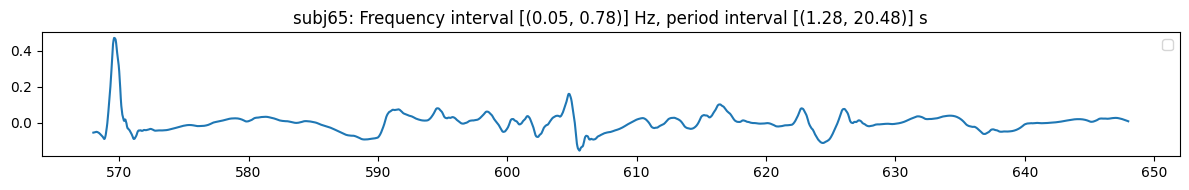

(<Figure size 1200x200 with 1 Axes>,
 [<Axes: title={'center': 'subj65: Frequency interval [(0.05, 0.78)] Hz, period interval [(1.28, 20.48)] s'}>])

In [ ]:
#| eval: false

dg0.face_t.project(features=['skew'], subjs=[65], fbands=[1,2,3,4], wdfactory=wfactory('db4',8)).plot_signal(subjs=[65])

 [DEBUG] piece.project: Calling BaseDatasource.project with subjs=[65], features=['kurtosis'], heatmap=None, fvector=None, fbands=[1, 2, 3, 4], pcfactory=None, wdfactory=<fhemb.utils.factories.ConcreteEmbFactory object>
 [DEBUG] piece._choose_embedding: Classified features: {'percentiles': [], 'bins': [], 'pcomponents': [], 'stat_features': ['kurtosis']}
 [DEBUG] piece._choose_embedding: classified stat_features: ['kurtosis']
 [DEBUG] piece.project: Chosen embeddings: [('features_ts', {'embedding': <fhemb.embedding.Embedding object>, 'features': ['kurtosis']})]
 [DEBUG] embedding.project: Calling project for subjects=[65] and features=['kurtosis'], heatmap=None, fvector=None, fbands=[1, 2, 3, 4], factory=<fhemb.utils.factories.ConcreteEmbFactory object>
 [DEBUG] mixins.wrapper: Calling _create_wdecomposition_impl with stacklevel=2
 [DEBUG] mixins.wrapper: Processing features ['kurtosis'], heatmap None, fvector None, args=(), and kwargs={'factory': <fhemb.utils.factories.ConcreteEmbFact

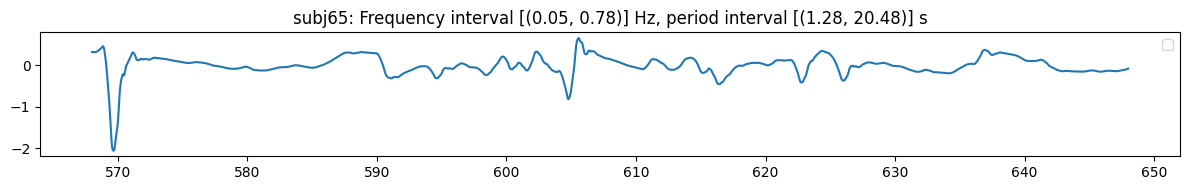

(<Figure size 1200x200 with 1 Axes>,
 [<Axes: title={'center': 'subj65: Frequency interval [(0.05, 0.78)] Hz, period interval [(1.28, 20.48)] s'}>])

In [ ]:
#| eval: false

dg0.face_t.project(features=['kurtosis'], subjs=[65], fbands=[1,2,3,4], wdfactory=wfactory('db4',8)).plot_signal(subjs=[65])

 [DEBUG] piece.project: Calling BaseDatasource.project with subjs=[65], features=['kurtosis', 'skew'], heatmap=None, fvector=None, fbands=[1, 2, 3, 4], pcfactory=<fhemb.utils.factories.ConcretePcaFactory object>, wdfactory=<fhemb.utils.factories.ConcreteEmbFactory object>
 [DEBUG] piece._choose_embedding: Classified features: {'percentiles': [], 'bins': [], 'pcomponents': [], 'stat_features': ['kurtosis', 'skew']}
 [DEBUG] piece._choose_embedding: classified stat_features: ['kurtosis', 'skew']
 [DEBUG] piece.project: Chosen embeddings: [('features_ts', {'embedding': <fhemb.embedding.Embedding object>, 'features': ['kurtosis', 'skew']})]
 [DEBUG] embedding.project: Calling project for subjects=[65] and features=['kurtosis', 'skew'], heatmap=None, fvector=None, fbands=[1, 2, 3, 4], factory=<fhemb.utils.factories.ConcreteEmbFactory object>
 [DEBUG] mixins.wrapper: Calling _create_wdecomposition_impl with stacklevel=2
 [DEBUG] mixins.wrapper: Processing features ['kurtosis', 'skew'], heatm

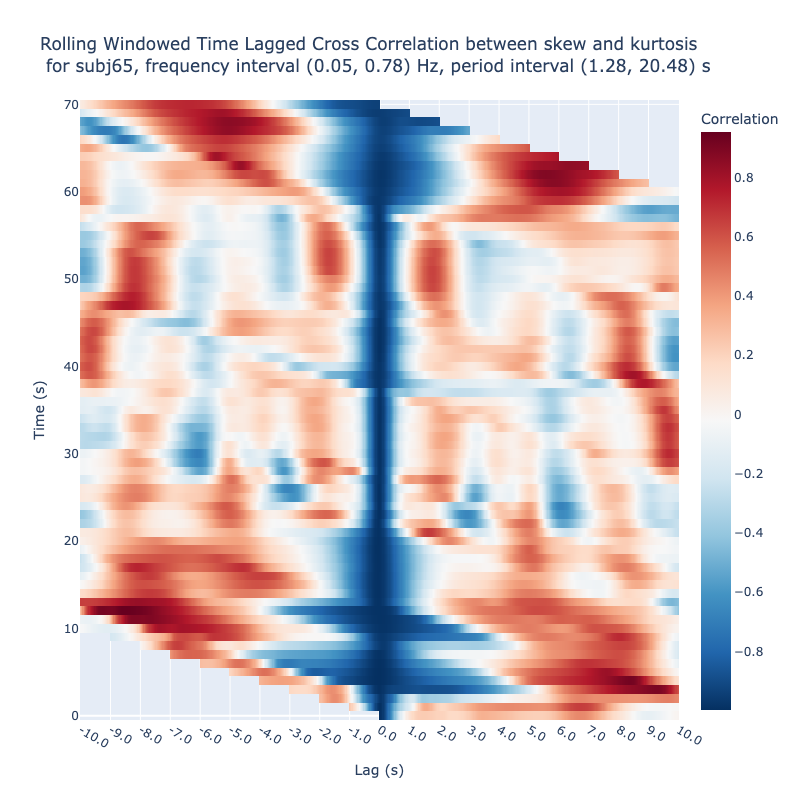

In [ ]:
#| eval: false

dg0.face_t.project(
    subjs=[65],
    features=['kurtosis', 'skew'],
    fbands=[1,2,3,4],
    wdfactory=wfactory('db4',8),
    pcfactory=pca2,
).plot_lagged_correlations(
    twin=250,
    step=25,
    max_lag=250,
    n_jobs=8
)

 [DEBUG] piece.project: Calling BaseDatasource.project with subjs=[65], features=['p10', 'kurtosis'], heatmap=None, fvector=None, fbands=[3, 4], pcfactory=<fhemb.utils.factories.ConcretePcaFactory object>, wdfactory=<fhemb.utils.factories.ConcreteEmbFactory object>
 [DEBUG] piece._choose_embedding: Classified features: {'percentiles': ['p10'], 'bins': [], 'pcomponents': [], 'stat_features': ['kurtosis']}
 [DEBUG] piece._choose_embedding: classified percentiles: ['p10']
 [DEBUG] piece._choose_embedding: classified stat_features: ['kurtosis']
 [DEBUG] piece.project: Chosen embeddings: [('percentiles_ts', {'embedding': <fhemb.embedding.Embedding object>, 'features': ['p10']}), ('features_ts', {'embedding': <fhemb.embedding.Embedding object>, 'features': ['kurtosis']})]
 [DEBUG] embedding.project: Calling project for subjects=[65] and features=['p10'], heatmap=None, fvector=None, fbands=[3, 4], factory=<fhemb.utils.factories.ConcreteEmbFactory object>
 [DEBUG] mixins.wrapper: Calling _crea

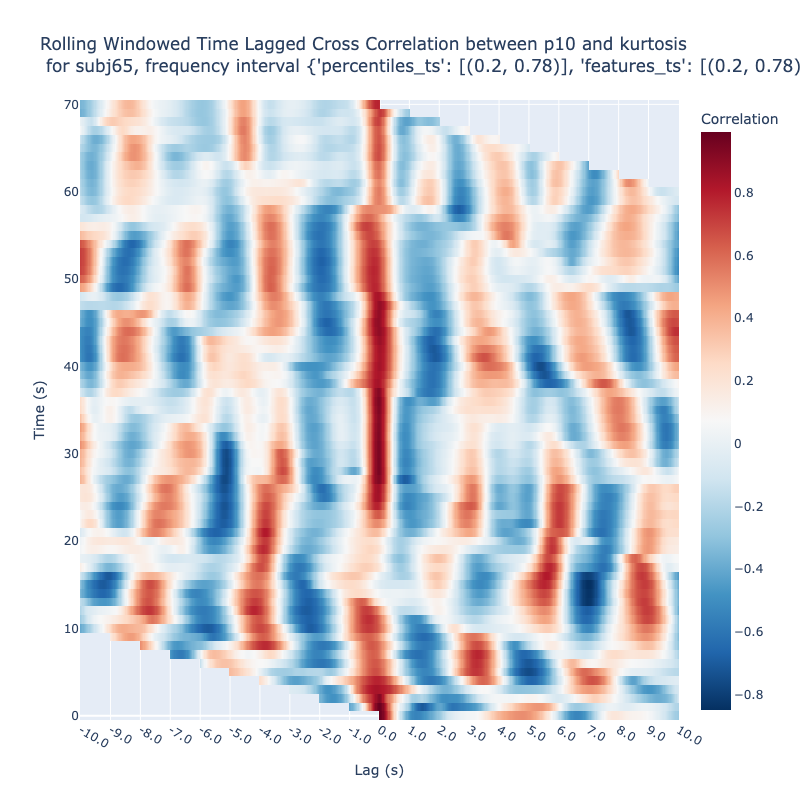

In [ ]:
#| eval: false

dg0.face_t.project(
    subjs=[65],
    features=['p10', 'kurtosis'],
    fbands=[3,4],
    wdfactory=wfactory('db4',8),
    pcfactory=pca2,
).plot_lagged_correlations(
    twin=250,
    step=25,
    max_lag=250,
    n_jobs=8
)

 [INFO] piece._load_from_db: Loading face_t from the database
 [INFO] piece._fetch_from_DB: Fetching data by query SELECT subj60, subj61, subj62, subj63, subj64, subj65, subj66, subj67, subj68, subj69, subj70 FROM dg.faceposition_t WHERE frame_number >= 14200 AND frame_number < 16200 ORDER BY frame_number
 [DEBUG] piece.start: SSH disabled; using direct DB connection
 [DEBUG] dbms.__enter__: Database connection opened: True (conn.closed=0)
 [DEBUG] dbms.__enter__: Database cursor opened: True
 [INFO] dbms.data_query: Fetching time series of ['subj60', 'subj61', 'subj62', 'subj63', 'subj64', 'subj65', 'subj66', 'subj67', 'subj68', 'subj69', 'subj70']
 [DEBUG] dbms.__exit__: __exit__ called with exc_type=None, 
exc_val=None, 
exc_tb=None
 [DEBUG] dbms.__exit__: Cursor closed: True
 [DEBUG] dbms.__exit__: Transaction committed
 [DEBUG] dbms.__exit__: Connection closed: True (conn.closed = 1)
 [INFO] piece.fetch_timeseries: 2000 rows fetched successfully!
 [INFO] piece._fetch_from_DB: Fetc

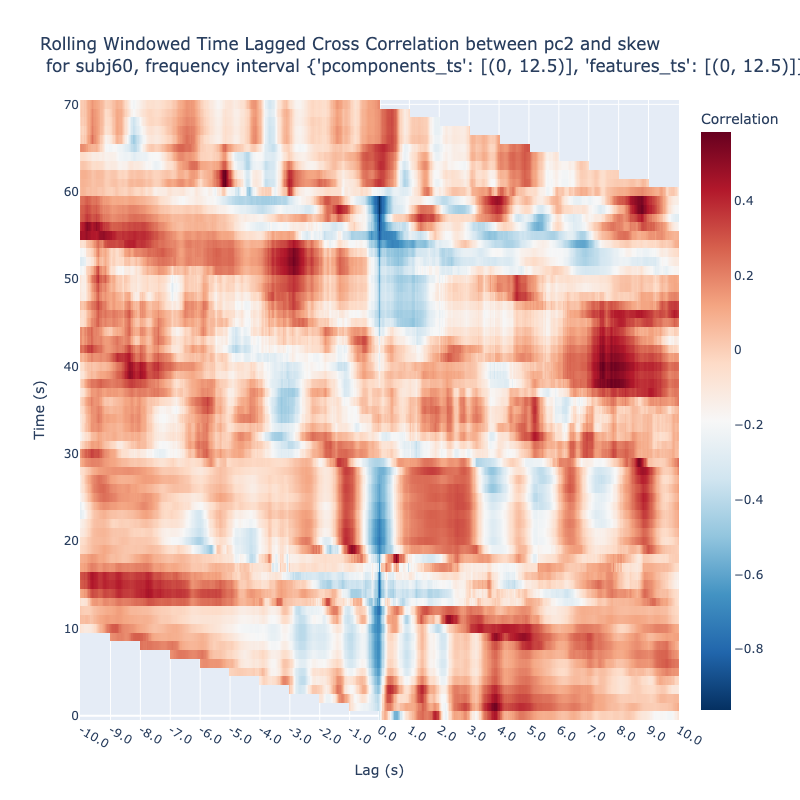

In [ ]:
#| eval: false

dg0.face_t.project(
    subjs=[60],
    features=['skew', 'pc2'],
    fbands=[0,1,2,3,4,5,6,7,8], 
    wdfactory=wfactory('db4',8),
    pcfactory=pca8 # robust_kpca_5_linear_1
).plot_lagged_correlations(
    twin=250,
    step=25,
    max_lag=250, 
    n_jobs=8    
)

 [DEBUG] piece.create_pca_embedding: Calling create_pca_embedding
 [DEBUG] tutils.create: Creating create_pca_embedding with args: RobustScaler(copy=True,quantile_range=(25.0, 75.0),unit_variance=False,with_centering=True,with_scaling=True) | KernelPCA(alpha=1.0,coef0=1,copy_X=True,degree=3,eigen_solver='auto',fit_inverse_transform=True,gamma=1,iterated_power='auto',kernel='linear',kernel_params=None,max_iter=None,n_components=5,n_jobs=None,random_state=None,remove_zero_eig=False,tol=0) and kwargs: dict_keys(['factory', 'datasource', 'subjects', 'time_interval', 'temperature_threshold'])
 [DEBUG] tutils.create: Using already calculated value for RobustScaler(copy=True,quantile_range=(25.0, 75.0),unit_variance=False,with_centering=True,with_scaling=True) | KernelPCA(alpha=1.0,coef0=1,copy_X=True,degree=3,eigen_solver='auto',fit_inverse_transform=True,gamma=1,iterated_power='auto',kernel='linear',kernel_params=None,max_iter=None,n_components=5,n_jobs=None,random_state=None,remove_zero_ei

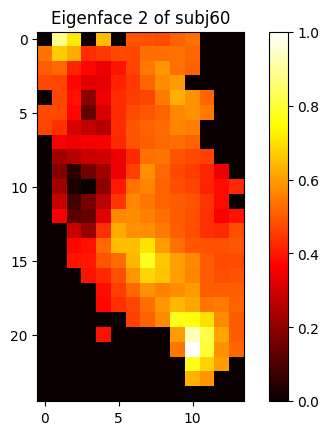

{'subj60': [<Figure size 640x480 with 2 Axes>]}

In [ ]:
#| eval: false

dg0.face_t.create_pca_embedding(factory=pca8)[0].visualize_eigenfaces(subjs=[60], components=[2])

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()